## AUC - ROC Curve

AUC: Area Under the receiver operating Characteristic (ROC) curve.

ROC: Reciever Operating Characteristic curve

ROC Curve plots the true positive (TP) rate versus the false positive (FP) rate at different classification thresholds

The thresholds are different probability cutoffs that separate the two classes in binary classification

It uses probability to tell us how well a model separates the classes.

## CASE: Imbalanced Data

Suppose we have an imbalanced data set where the majority of our data is of one value. 

We can obtain high accuracy for the model by predicting the majority class.

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

n = 10000
ratio = .95
n_0 = int((1-ratio) * n)
n_1 = int(ratio * n)

y = np.array([0] * n_0 + [1] * n_1)
# below are the probabilities obtained from a hypothetical model that always predicts the majority class
# probability of predicting class 1 is going to be 100%
y_proba = np.array([1]*n)
y_pred = y_proba > .5

print(f'accuracy score: {accuracy_score(y, y_pred)}')
cf_mat = confusion_matrix(y, y_pred)
print('Confusion matrix')
print(cf_mat)
print(f'class 0 accuracy: {cf_mat[0][0]/n_0}')
print(f'class 1 accuracy: {cf_mat[1][1]/n_1}')

accuracy score: 0.95
Confusion matrix
[[   0  500]
 [   0 9500]]
class 0 accuracy: 0.0
class 1 accuracy: 1.0


Although we obtain a very high accuracy, the model provided no information about the data so it's not useful. 

We accurately predict class 1 100% of the time while inaccurately predict class 0 0% of the time. 
    
At the expense of accuracy, it might be better to have a model that can somewhat separate the two classes

In [3]:
# below are the probabilities obtained from a hypothetical model that doesn't always predict the mode
y_proba_2 = np.array(
    np.random.uniform(0, .7, n_0).tolist() +
    np.random.uniform(.3, 1, n_1).tolist()
)
y_pred_2 = y_proba_2 > .5

print(f'accuracy score: {accuracy_score(y, y_pred_2)}')
cf_mat = confusion_matrix(y, y_pred_2)
print('Confusion matrix')
print(cf_mat)
print(f'class 0 accuracy: {cf_mat[0][0]/n_0}')
print(f'class 1 accuracy: {cf_mat[1][1]/n_1}')

accuracy score: 0.7161
Confusion matrix
[[ 372  128]
 [2711 6789]]
class 0 accuracy: 0.744
class 1 accuracy: 0.7146315789473684


For the second set of predictions, we do not have as high of an accuracy score as the first.  
but the accuracy for each class is more balanced. 

Using accuracy as an evaluation metric we would rate the first model higher than the second.
even though it doesn't tell us anything about the data.

In cases like this, using another evaluation metric like AUC would be preferred.

In [4]:
import matplotlib.pyplot as plt

def plot_roc_curve(true_y, y_prob):
    """
    plots the roc curve based of the probabilities
    """

    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()

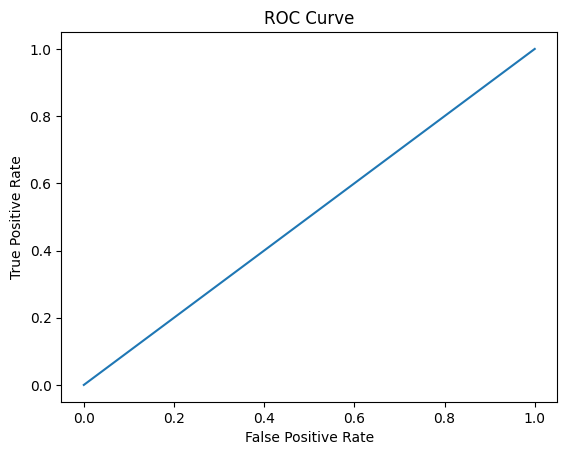

model 1 AUC score: 0.5


In [5]:
# Model 1:
plot_roc_curve(y, y_proba)
print(f'model 1 AUC score: {roc_auc_score(y, y_proba)}')

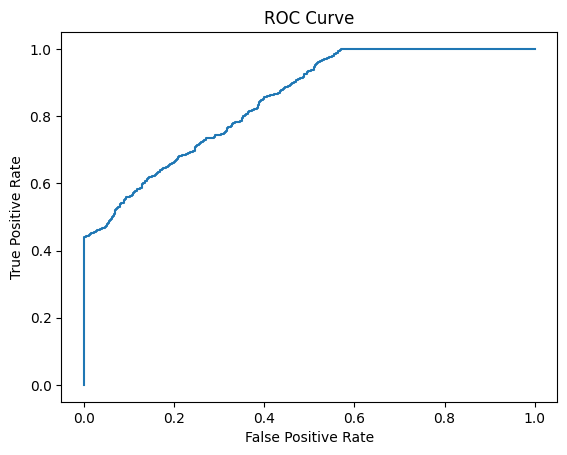

model 2 AUC score: 0.8470989473684211


In [6]:
# Model 2
plot_roc_curve(y, y_proba_2)
print(f'model 2 AUC score: {roc_auc_score(y, y_proba_2)}')

An AUC score of around .5 would mean that the model is unable to make a distinction between the two classes and the curve would look like a line with a slope of 1. An AUC score closer to 1 means that the model has the ability to separate the two classes and the curve would come closer to the top left corner of the graph.



##  Probabilities
Because AUC is a metric that utilizes probabilities of the class predictions, we can be more confident in a model that has a higher AUC score than one with a lower score even if they have similar accuracies.

In the data below, we have two sets of probabilites from hypothetical models. The first has probabilities that are not as "confident" when predicting the two classes (the probabilities are close to .5). The second has probabilities that are more "confident" when predicting the two classes (the probabilities are close to the extremes of 0 or 1).

In [7]:
# First Case: model 1 has higher accuracy but lower AUC score than model 2

import numpy as np

n = 10000
y = np.array([0] * n + [1] * n)
#
y_prob_1 = np.array(
    np.random.uniform(.25, .5, n//2).tolist() +
    np.random.uniform(.3, .7, n).tolist() +
    np.random.uniform(.5, .75, n//2).tolist()
)
y_prob_2 = np.array(
    np.random.uniform(0, .4, n//2).tolist() +
    np.random.uniform(.3, .7, n).tolist() +
    np.random.uniform(.6, 1, n//2).tolist()
)

print(f'model 1 accuracy score: {accuracy_score(y, y_prob_1>.5)}')
print(f'model 2 accuracy score: {accuracy_score(y, y_prob_2>.5)}')

print(f'model 1 AUC score: {roc_auc_score(y, y_prob_1)}')
print(f'model 2 AUC score: {roc_auc_score(y, y_prob_2)}')


model 1 accuracy score: 0.7482
model 2 accuracy score: 0.74845
model 1 AUC score: 0.77521897
model 2 AUC score: 0.8582889


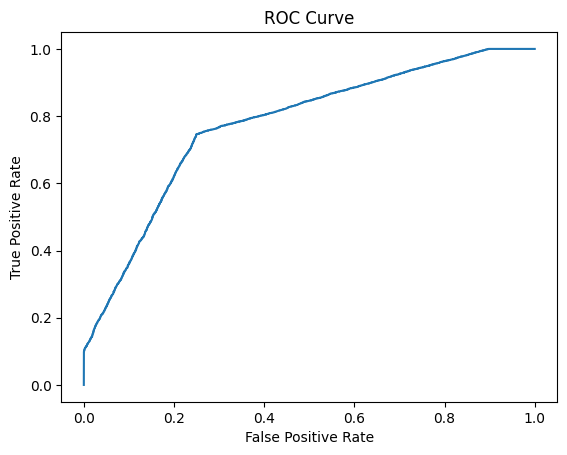

In [8]:
# Plot Model 1 ROC curve
plot_roc_curve(y, y_prob_1)

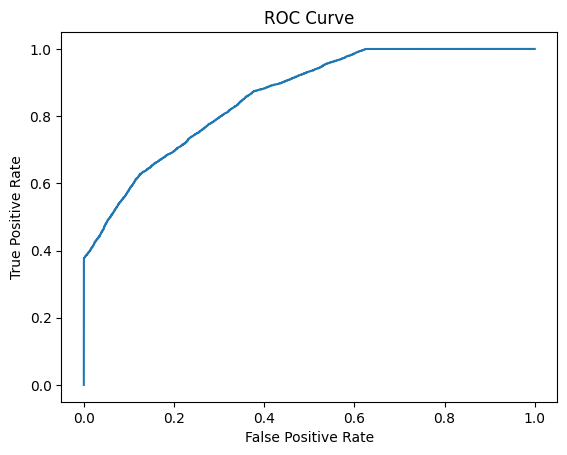

In [9]:
# Plot Model 2 ROC curve
plot_roc_curve(y, y_prob_2)